# 01 - Proposal Exploration

Initial dataset profiling to support the project proposal for **Prinsip Sains Data** course.

Dataset: Student Exam Performance Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

## 1. Load Dataset

In [2]:
df = pd.read_csv('../datasets/student_exam_performance_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 23)


,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


## 2. Data Types & Missing Values

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')

=== Data Types ===
student_id                     object
gender                         object
age                             int64
parental_education             object
family_income                  object
internet_access                object
study_environment              object
study_hours_per_day           float64
attendance_rate               float64
sleep_hours                   float64
social_media_hours            float64
assignment_completion_rate    float64
participation_score           float64
online_courses_completed        int64
tutoring                       object
math_score                    float64
reading_score                 float64
writing_score                 float64
science_score                 float64
final_exam_score              float64
previous_gpa                  float64
pass_fail                      object
grade_category                 object
dtype: object

=== Missing Values ===
No missing values found


## 3. Categorical Distributions

In [4]:
categorical_cols = ['gender', 'parental_education', 'family_income',
                    'internet_access', 'study_environment', 'tutoring',
                    'pass_fail', 'grade_category']

for col in categorical_cols:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())


gender:
gender
Male      5013
Female    4987

parental_education:
parental_education
High School    3926
Bachelor       3502
Master         2047
PhD             525

family_income:
family_income
Medium    5068
Low       2971
High      1961

internet_access:
internet_access
Yes    8986
No     1014

study_environment:
study_environment
Quiet       4073
Moderate    3947
Noisy       1980

tutoring:
tutoring
No     7004
Yes    2996

pass_fail:
pass_fail
Fail    5142
Pass    4858

grade_category:
grade_category
F    5172
D    3829
C     904
B      85
A      10


## 4. Numeric Summary Statistics

In [5]:
df.describe().round(2)

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,16.49,3.02,84.70,7.02,2.52,79.49,69.82,2.03,49.50,49.76,49.65,49.76,49.68,1.98
std,1.12,1.18,9.51,0.99,1.45,13.76,14.66,1.44,13.88,13.36,13.44,13.83,12.15,0.54
min,15.00,0.50,50.80,4.00,0.00,40.00,20.00,0.00,0.00,0.00,0.00,4.80,4.40,0.00
25%,15.00,2.20,78.28,6.34,1.50,70.20,59.80,1.00,40.00,40.80,40.70,40.30,41.60,1.61
50%,16.00,3.01,85.10,7.03,2.50,80.00,69.90,2.00,49.30,49.60,49.60,49.60,49.55,1.99
75%,17.00,3.83,91.90,7.69,3.50,90.00,80.10,3.00,58.60,58.50,58.60,59.00,57.60,2.35
max,18.00,7.24,100.00,10.00,8.00,100.00,100.00,9.00,100.00,100.00,100.00,100.00,97.80,3.99


## 5. Correlation Matrix

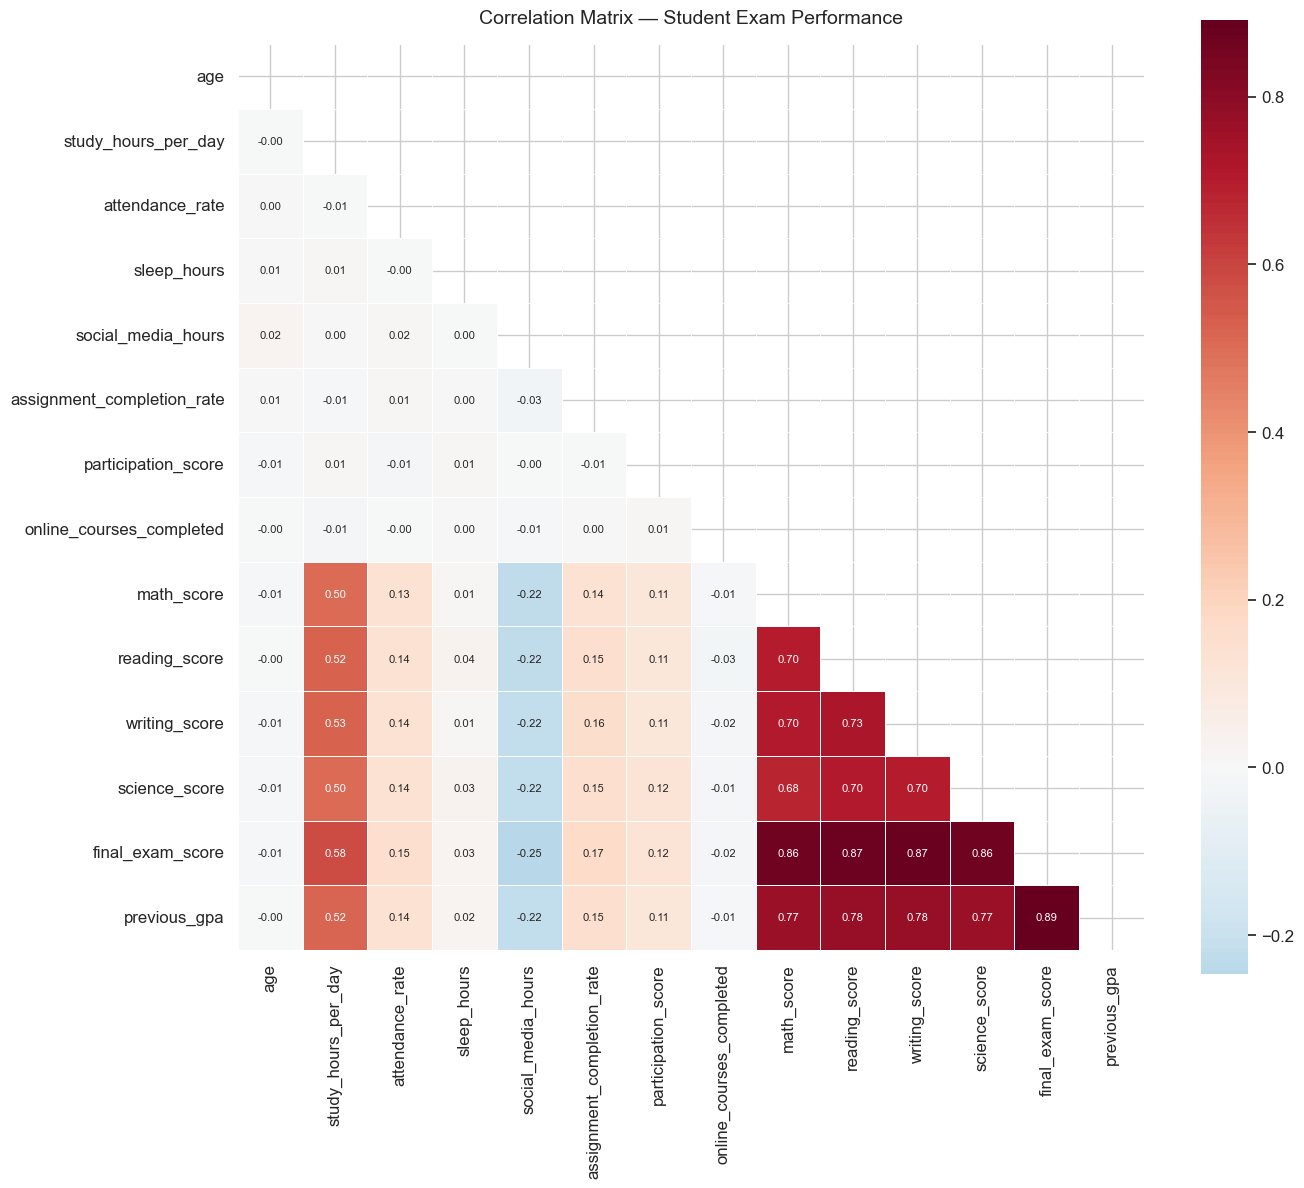

In [6]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix — Student Exam Performance', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../deliverables/proposal/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Correlations with Final Exam Score

In [7]:
target_corr = corr['final_exam_score'].drop('final_exam_score').sort_values(key=abs, ascending=False)
print('Top 10 correlations with final_exam_score:')
print(target_corr.head(10).round(4))

Top 10 correlations with final_exam_score:
previous_gpa                  0.8912
writing_score                 0.8745
reading_score                 0.8725
math_score                    0.8639
science_score                 0.8627
study_hours_per_day           0.5758
social_media_hours           -0.2463
assignment_completion_rate    0.1707
attendance_rate               0.1506
participation_score           0.1239
Name: final_exam_score, dtype: float64


## 7. Quick Distribution Plots

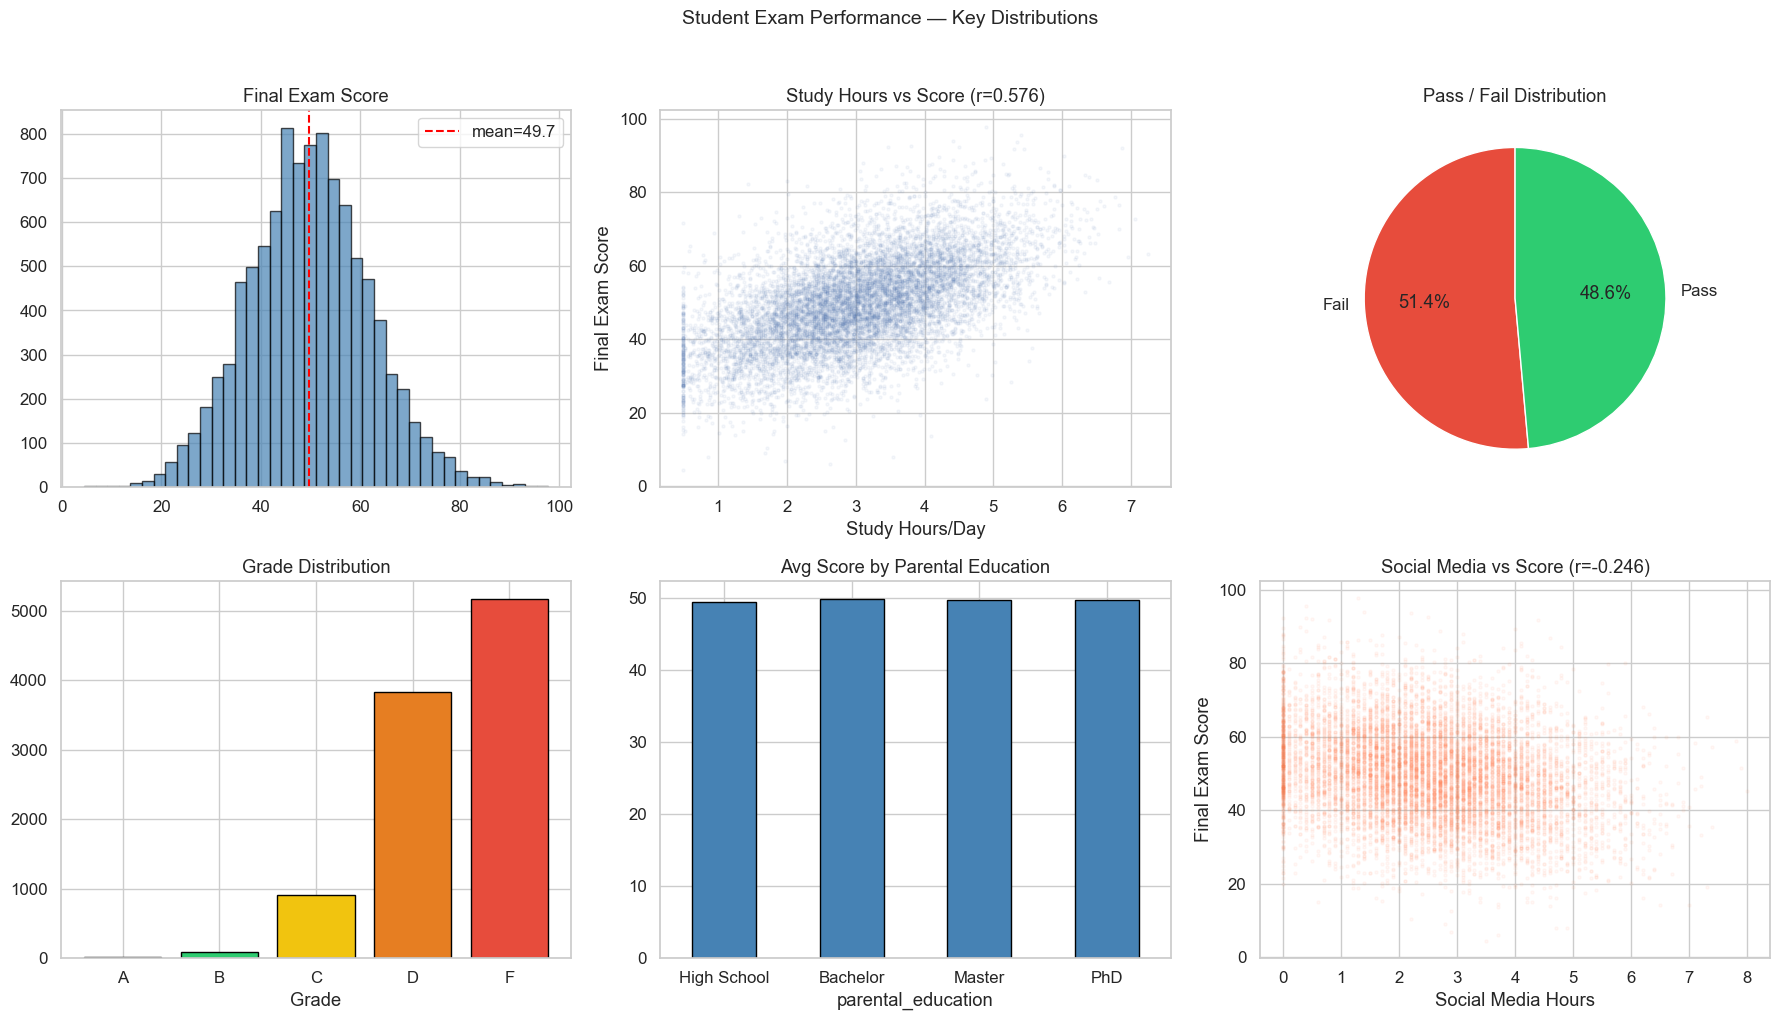

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Final exam score distribution
axes[0][0].hist(df['final_exam_score'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0][0].axvline(df['final_exam_score'].mean(), color='red', linestyle='--', label=f"mean={df['final_exam_score'].mean():.1f}")
axes[0][0].set_title('Final Exam Score')
axes[0][0].legend()

# Study hours vs final exam score
axes[0][1].scatter(df['study_hours_per_day'], df['final_exam_score'], alpha=0.05, s=5)
axes[0][1].set_xlabel('Study Hours/Day')
axes[0][1].set_ylabel('Final Exam Score')
axes[0][1].set_title(f'Study Hours vs Score (r={df["study_hours_per_day"].corr(df["final_exam_score"]):.3f})')

# Pass/Fail pie
pf = df['pass_fail'].value_counts()
axes[0][2].pie(pf, labels=pf.index, autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0][2].set_title('Pass / Fail Distribution')

# Grade category bar
grade_order = ['A', 'B', 'C', 'D', 'F']
gc = df['grade_category'].value_counts().reindex(grade_order)
axes[1][0].bar(gc.index, gc.values, color=['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c'], edgecolor='black')
axes[1][0].set_title('Grade Distribution')
axes[1][0].set_xlabel('Grade')

# Score by parental education
df.groupby('parental_education')['final_exam_score'].mean().reindex(
    ['High School', 'Bachelor', 'Master', 'PhD']).plot(
    kind='bar', ax=axes[1][1], color='steelblue', edgecolor='black')
axes[1][1].set_title('Avg Score by Parental Education')
axes[1][1].tick_params(axis='x', rotation=0)

# Social media vs score
axes[1][2].scatter(df['social_media_hours'], df['final_exam_score'], alpha=0.05, s=5, color='coral')
axes[1][2].set_xlabel('Social Media Hours')
axes[1][2].set_ylabel('Final Exam Score')
axes[1][2].set_title(f'Social Media vs Score (r={df["social_media_hours"].corr(df["final_exam_score"]):.3f})')

plt.suptitle('Student Exam Performance — Key Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../deliverables/proposal/key_distributions.png', dpi=150, bbox_inches='tight')
plt.show()